In [42]:
import pandas as pd
import numpy as np

channels = pd.read_excel("../data/tg_channels.xlsx")
df = pd.read_parquet("../data/dataset_tg_economic.parquet")[["message_id", "id_channel", "message", "date", "viral_final", "is_economic", "topic"]]
print(df.shape)

full = pd.read_parquet("../data/tg_news_full.parquet")
print(full.shape)


/home/mlcore/conda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


(44760, 7)
(123273, 9)


In [43]:
full

,post_uuid,message_id,date,message,id_channel,message_vector,id,name,subscribers
0,e46cf62f-2d16-4c73-93b1-1b3952b95e3e,275548,2025-01-02 17:00:02,"Правительство Словакии обсудит меры, которые м...",3,'адекватн':11 'газ':18 'заяв':21 'зеленск':15 ...,3,Риа Новости,3385000
1,792632e5-da04-4341-a674-f8405c8ddd71,275547,2025-01-02 16:40:53,В ДТП с туристическим автобусом в Таиланде пос...,3,'27':9 'автобус':5 'возвращен':31 'гостиниц':3...,3,Риа Новости,3385000
2,dcb05245-5965-4003-81a5-421043394def,275546,2025-01-02 16:20:12,Премьер Израиля Нетаньяху выписан из больницы ...,3,'jerusalem':14 'post':15 'больниц':6 'выписа':...,3,Риа Новости,3385000
3,e91db7c4-d272-4b0b-82f9-425016288476,275545,2025-01-02 15:54:29,Подозреваемый в подрыве автомобиля Tesla Cyber...,3,'cybertruck':6 'tesla':5 'автомобил':4 'вегас'...,3,Риа Новости,3385000
4,c702e716-6806-497b-83ba-764eee4f82e3,275543,2025-01-02 15:32:55,Спецоперация. Обстановка и главные события на ...,3,'-27':33 '1200':16 '13':63 '155':96 '2':7 '202...,3,Риа Новости,3385000
...,...,...,...,...,...,...,...,...,...
123268,f22a8555-efc0-4487-88ca-2ba1a81fb0be,275554,2025-01-02 18:31:01,Турецкая авиакомпания Turkish Airlines отреаги...,3,'airlin':4 'new':25 'time':27 'turkish':3 'yor...,3,Риа Новости,3385000
123269,70beeef1-1e67-4446-b386-4b75e2c30f5e,275553,2025-01-02 18:11:07,Фицо пригрозил снижением помощи украинцам в Сл...,3,'газ':12 'киев':10 'остановк':9 'помощ':4 'при...,3,Риа Новости,3385000
123270,14a3bfd3-b462-4cc1-ac44-9b38ea1ebfba,275552,2025-01-02 18:02:44,Административные здания Верховной рады Украины...,3,'административн':1 'верховн':3 'взрыв':9 'здан...,3,Риа Новости,3385000
123271,e3875495-5156-4c1c-a774-1e9b21b1a1e7,275551,2025-01-02 17:50:58,Новые загрязнения побережья нефтепродуктами в ...,3,'загрязнен':2 'крым':6 'ликвидирова':7 'мчс':9...,3,Риа Новости,3385000


In [44]:
df_q = pd.read_csv("../data/labeled_posts_full.csv")[["message_id", "id_channel", "message", "viral_final", "is_economic", "topic"]]
df_q.shape

/tmp/ipykernel_467/1936668200.py:1: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_q = pd.read_csv("../data/labeled_posts_full.csv")[["message_id", "id_channel", "message", "viral_final", "is_economic", "topic"]]


(67255, 6)

In [45]:
df_q = df_q.merge(full[["post_uuid", "date"]], left_on="message_id", right_on="post_uuid", how="left").drop("post_uuid", axis=1)
df_q.head()

,message_id,id_channel,message,viral_final,is_economic,topic,date
0,00027151-a524-4d93-a820-116398fb81bb,3,"Европа делает ""самоубийственное движение"", ког...",0.468767,False,NaN,2025-04-07 11:53:51
1,0003b835-cf4a-43ff-b155-a144cf56b7f8,3,Верховный суд Ингушетии отправил под арест быв...,0.428130,False,NaN,2025-07-29 20:55:09
2,0005535a-74a9-4cb9-853f-ce04612d2f94,3,Свыше миллиона детей пойдут в первый класс в э...,0.456934,False,NaN,2025-04-01 13:53:43
3,00064231-2c13-48f7-8f07-9abf2b049b89,1,❗️Бывший президент Сирии Башар Асад накануне с...,0.666604,False,NaN,2024-12-09 15:35:06
4,0006e10d-39d5-48fd-b5d8-3fbc732d09f4,6,Сегодня на рынке жилья сложилась патовая ситуа...,0.746281,True,Макроэкономика,2024-11-05 08:10:16


In [80]:
goldenset = pd.read_csv("../data/golden_set_v1.csv")

In [81]:
goldenset = goldenset.merge(df_q[["message_id", "viral_final", "id_channel", "date"]], on="message_id", how="left")
goldenset

,message_id,message,topic,reason,economic_narrative,narrative_strength,economic_effect,information_resonance,viral_final,id_channel,date
0,8c497c96-be46-4bb4-888f-25e40d20debb,#POSI \nГК Позитив — лидер в рейтинге покупок ...,Рынки капитала,Новость описывает активные покупки акций и изм...,0,0.00,0.00,0.00,0.440763,2,2025-07-01 13:28:09
1,63c159f3-4205-4477-bb06-e00c0bde9187,⚡️Россельхознадзор опроверг запрет на ввоз ман...,Международная торговля,Новость сообщает о заявленном запрете (и его о...,0,0.00,0.50,0.25,0.651092,1,2024-12-06 13:43:05
2,e189e8c9-28c2-4160-92e2-fc929057f2cc,Корпоративные бонды с доходностью 20-21%+ — се...,Рынки капитала,"Текст посвящён корпоративным облигациям, их до...",0,0.10,0.10,0.10,0.676079,2,2024-08-07 07:32:45
3,db2e74c1-fefa-4333-823c-6e0a527e87a0,#MTLR\n🪨 Мечел в 2025г может сократить отгрузк...,Корпоративные финансы,Новость описывает финансовые решения Mechel: с...,0,0.00,-0.25,0.25,0.544580,2,2025-06-30 06:51:47
4,031d93c6-89f0-426a-ada0-9f6f4174f4b7,Россия вошла в топ-5 стран по оттоку миллионер...,Макроэкономика,Новость сообщает о масштабном оттоке миллионер...,1,0.50,-0.50,0.75,0.636313,18,2024-06-19 05:31:11
...,...,...,...,...,...,...,...,...,...,...,...
495,968b6c17-2bc9-4828-9fac-6868b5a838db,⚡️Курс евро на межбанковском рынке опустился н...,Валютный рынок,Текст сообщает о движении курса евро к рублю н...,0,0.25,0.50,0.25,0.460295,1,2025-02-12 08:19:29
496,632250bd-e051-4061-a49f-6419180ac047,X5 стала лидером онлайн-продаж товаров повседн...,Корпоративные финансы,Новость содержит конкретные финансовые показат...,0,0.25,-0.25,0.00,0.405514,1,2025-02-20 11:25:06
497,75e06c71-8823-4cb5-9e13-8a96e003e11d,⚡️Минтруд РФ предложил не брать иностранцев на...,Государственная экономическая политика,Новость описывает предложение Минтруда о регул...,1,0.50,0.50,0.50,0.389320,1,2025-08-01 13:06:42
498,938733b1-c1d4-4d32-a457-968e22d280fd,"ЦБ и Минфин разошлись во мнении, как устранить...",Корпоративные финансы,Новость описывает налоговые проблемы при IPO и...,0,0.00,0.00,0.25,0.351437,6,2025-04-25 09:13:54


In [82]:
goldenset.to_csv("../data/golden_set_v2.csv")

In [83]:
print(df.shape)
df.head()

(44760, 10)


,message_id,id_channel,message,date,viral_final,is_economic,topic,channel_name,channel_w,date_day
0,00027151-a524-4d93-a820-116398fb81bb,3,"Европа делает ""самоубийственное движение"", ког...",2025-04-07 11:53:51+00:00,0.406649,False,None,Риа Новости,1.000000,2025-04-07 00:00:00+00:00
1,0003b835-cf4a-43ff-b155-a144cf56b7f8,3,Верховный суд Ингушетии отправил под арест быв...,2025-07-29 20:55:09+00:00,0.445509,False,None,Риа Новости,1.000000,2025-07-29 00:00:00+00:00
2,0005535a-74a9-4cb9-853f-ce04612d2f94,3,Свыше миллиона детей пойдут в первый класс в э...,2025-04-01 13:53:43+00:00,0.396754,False,None,Риа Новости,1.000000,2025-04-01 00:00:00+00:00
3,0007e2f8-787d-404f-91ff-e2582096a4a7,18,Сербия согласна поддержать санкции Евросоюза п...,2025-07-26 07:01:09+00:00,0.703622,True,Санкции и геополитика,Экономика,0.009202,2025-07-26 00:00:00+00:00
4,000884a5-8291-4ec1-805f-ac131112aaf7,6,Китайский рынок акций упал сильнее всего с апр...,2025-09-04 10:16:56+00:00,0.680369,True,Рынки капитала,Forbes Russia,0.182985,2025-09-04 00:00:00+00:00


In [52]:
def attach_channel_w(
    df: pd.DataFrame,
    channels_df: pd.DataFrame,
    news_id_col: str = "id_channel",
    chan_id_col: str = "id",
    subs_col: str = "subscribers",
    weight_col: str = "channel_w",) -> pd.DataFrame:
    ch = channels_df[[chan_id_col, subs_col]].copy()
    ch[chan_id_col] = pd.to_numeric(ch[chan_id_col], errors="coerce").astype("Int64")
    ch[subs_col] = pd.to_numeric(ch[subs_col], errors="coerce").fillna(0).astype(float)
    id2subs = dict(zip(ch[chan_id_col], ch[subs_col]))

    out = df.copy()
    out[news_id_col] = pd.to_numeric(out[news_id_col], errors="coerce").astype("Int64")

    subs = out[news_id_col].map(id2subs).fillna(0.0).to_numpy(dtype=np.float32)
    log_subs = np.log1p(subs)

    mn, mx = float(log_subs.min()), float(log_subs.max())
    if mx > mn:
        w = (log_subs - mn) / (mx - mn)
    else:
        w = np.zeros_like(log_subs, dtype=np.float32)

    out[weight_col] = w.astype(np.float32)
    return out


In [53]:
ch_map = (channels[["id", "name"]]
          .dropna()
          .assign(id=lambda x: pd.to_numeric(x["id"], errors="coerce"))
          .dropna(subset=["id"])
          .assign(id=lambda x: x["id"].astype(int))
          .set_index("id")["name"]
          .to_dict())

df = df.copy()
df["id_channel"] = pd.to_numeric(df["id_channel"], errors="coerce")
df["channel_name"] = df["id_channel"].map(ch_map).fillna(df["id_channel"].astype("Int64").astype(str))
df = attach_channel_w(df, channels)

In [54]:
import re
import numpy as np
import pandas as pd

def clean_news_text(t: str) -> str:
    t = t or ""
    t = re.sub(r"#\w+", " ", t)
    t = re.sub(r"[⚡️📈📉🇷🇺✅❗️🔥⬛ ⬜ ⚫ ⚪🔹]+", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

def ensure_datetime(df: pd.DataFrame, col: str = "date") -> pd.DataFrame:
    d = df.copy()
    d[col] = pd.to_datetime(d[col], utc=True, errors="coerce")
    d = d.dropna(subset=[col])
    d["date_day"] = d[col].dt.floor("D")
    return d

df = ensure_datetime(df, "date")
df["message_id"] = df["message_id"].astype(str)
df["message"] = df["message"].fillna("").astype(str).map(clean_news_text)

In [84]:
df.head()

,message_id,id_channel,message,date,viral_final,is_economic,topic,channel_name,channel_w,date_day
0,00027151-a524-4d93-a820-116398fb81bb,3,"Европа делает ""самоубийственное движение"", ког...",2025-04-07 11:53:51+00:00,0.406649,False,None,Риа Новости,1.000000,2025-04-07 00:00:00+00:00
1,0003b835-cf4a-43ff-b155-a144cf56b7f8,3,Верховный суд Ингушетии отправил под арест быв...,2025-07-29 20:55:09+00:00,0.445509,False,None,Риа Новости,1.000000,2025-07-29 00:00:00+00:00
2,0005535a-74a9-4cb9-853f-ce04612d2f94,3,Свыше миллиона детей пойдут в первый класс в э...,2025-04-01 13:53:43+00:00,0.396754,False,None,Риа Новости,1.000000,2025-04-01 00:00:00+00:00
3,0007e2f8-787d-404f-91ff-e2582096a4a7,18,Сербия согласна поддержать санкции Евросоюза п...,2025-07-26 07:01:09+00:00,0.703622,True,Санкции и геополитика,Экономика,0.009202,2025-07-26 00:00:00+00:00
4,000884a5-8291-4ec1-805f-ac131112aaf7,6,Китайский рынок акций упал сильнее всего с апр...,2025-09-04 10:16:56+00:00,0.680369,True,Рынки капитала,Forbes Russia,0.182985,2025-09-04 00:00:00+00:00


In [86]:
df.to_csv("../data/prod_economic_data.csv", index=False)

In [57]:
from rank_bm25 import BM25Okapi

def tokenize_ru(text: str):
    text = text.lower()
    text = re.sub(r"[^0-9a-zа-яё\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

corpus_tok = [tokenize_ru(t) for t in df["message"].tolist()]
bm25 = BM25Okapi(corpus_tok)

In [58]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "intfloat/multilingual-e5-large" 
encoder = SentenceTransformer(MODEL_NAME, device="cuda")  
texts = df["message"].tolist()
doc_inputs = ["passage: " + t for t in texts]

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

In [59]:
# E_docs = encoder.encode(
#     doc_inputs,
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True,
# ).astype(np.float32)

In [60]:
# import faiss

# dim = E_docs.shape[1]
# index = faiss.IndexFlatIP(dim)      
# index.add(E_docs)

In [61]:
# # save
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import faiss
# import pickle

# OUT = Path("indexes")
# OUT.mkdir(parents=True, exist_ok=True)

# #rowmap
# rowmap = df[["message_id","date","date_day","id_channel","channel_name"]].copy()
# rowmap.to_parquet(OUT / "rowmap.parquet", index=False)

# np.save(OUT / "E_docs_e5_large.npy", E_docs)

# faiss.write_index(index, str(OUT / "faiss_e5_large.index"))

# with open(OUT / "bm25_corpus_tok.pkl", "wb") as f:
#     pickle.dump(corpus_tok, f)


In [62]:
# load
from pathlib import Path
import numpy as np
import pandas as pd
import faiss
import pickle

INP = Path("indexes")

rowmap = pd.read_parquet(INP / "rowmap.parquet")

E_docs = np.load(INP / "E_docs_e5_large.npy")
index = faiss.read_index(str(INP / "faiss_e5_large.index"))

with open(INP / "bm25_corpus_tok.pkl", "rb") as f:
    corpus_tok = pickle.load(f)

from rank_bm25 import BM25Okapi
bm25 = BM25Okapi(corpus_tok)


In [63]:
assert len(rowmap) == E_docs.shape[0]
assert len(rowmap) == index.ntotal

In [64]:
# %% [Cell 1] Imports + small helpers
import numpy as np
import pandas as pd

from typing import Optional, Union, Callable
import re
import json


def snippet(t: str, n: int = 1000) -> str:
    return (t or "")[:n]


def _topk_indices_from_scores(scores: np.ndarray, k: int) -> np.ndarray:
    k = min(k, len(scores))
    if k <= 0:
        return np.array([], dtype=int)
    if k == len(scores):
        idx = np.argsort(-scores)
    else:
        idx = np.argpartition(-scores, k - 1)[:k]
        idx = idx[np.argsort(-scores[idx])]
    return idx.astype(int)


In [65]:
# %% [Cell 2] Dense retrieval (FAISS) + time utilities

def dense_candidates_faiss(index, encoder, query: str, topN: int = 500):
    qv = encoder.encode(
        ["query: " + query],
        normalize_embeddings=True,
        show_progress_bar=False
    ).astype(np.float32)
    scores, idx = index.search(qv, topN)
    return idx[0].astype(int), scores[0].astype(np.float32)


def _compute_time_arrays(df: pd.DataFrame, rowpos: np.ndarray, anchor_date, date_col: str):
    ad = pd.to_datetime(anchor_date, utc=True).normalize()
    dts = pd.to_datetime(df.loc[rowpos, date_col], errors="coerce", utc=True).dt.normalize()
    age = (ad - dts).dt.days.to_numpy(dtype=np.float32)
    age = np.where(np.isfinite(age), age, 1e9).astype(np.float32)
    age = np.where(age < 0, 1e9, age).astype(np.float32)
    return dts, age


def _time_rank_from_age(age_days: np.ndarray) -> np.ndarray:
    order = np.argsort(age_days, kind="stable")
    rank = np.empty_like(order, dtype=np.int32)
    rank[order] = np.arange(1, len(order) + 1, dtype=np.int32)
    return rank


In [66]:
# %% [Cell 3] RRF hybrid retrieval (returns candidate pool; includes dense_score & bm25_score)

def hybrid_retrieve_rrf(
    df: pd.DataFrame,
    index,
    encoder,
    bm25,
    tokenize_fn: Callable[[str], list],
    query: str,
    k: Optional[int] = None,            # <- default None: return ALL candidates in the union
    topN_each: int = 500,
    k_rrf: int = 60,
    w_dense: float = 1.0,
    w_bm25: float = 1.0,
    anchor_date: Union[str, pd.Timestamp, None] = None,
    date_col: str = "date_day",
    max_window_days: Optional[int] = 365,
    w_time: float = 0.5,
    w_channel: Optional[float] = None,
    channel_w_col: str = "channel_w",
    # optional viral
    w_viral: Optional[float] = None,
    viral_col: str = "viral_final",
) -> pd.DataFrame:
    # ---- allowed mask by time window
    if anchor_date is not None:
        ad = pd.to_datetime(anchor_date, utc=True).normalize()
        if date_col not in df.columns:
            raise KeyError(f"date_col='{date_col}' not found in df.columns")
        dts_all = pd.to_datetime(df[date_col], errors="coerce", utc=True).dt.normalize()
        allowed = (dts_all <= ad)
        if max_window_days is not None:
            age_all = (ad - dts_all).dt.days
            allowed &= (age_all >= 0) & (age_all <= int(max_window_days))
        allowed_np = allowed.to_numpy(dtype=bool)
    else:
        allowed_np = None

    # ---- dense
    d_idx, d_sc = dense_candidates_faiss(index, encoder, query, topN=topN_each)
    if allowed_np is not None and len(d_idx) > 0:
        keep_mask = allowed_np[d_idx]
        d_idx = d_idx[keep_mask]
        d_sc = d_sc[keep_mask]

    dense_rank = {int(rowpos): r for r, rowpos in enumerate(d_idx, start=1)}
    dense_score = {int(rowpos): float(sc) for rowpos, sc in zip(d_idx, d_sc)}

    # ---- bm25 optional
    bm_scores = None
    bm_rank = {}
    if bm25 is not None:
        bm_scores = bm25.get_scores(tokenize_fn(query)).astype(np.float32)
        if allowed_np is not None:
            bm_scores[~allowed_np] = -np.inf
        b_idx = _topk_indices_from_scores(bm_scores, topN_each)
        bm_rank = {int(rowpos): r for r, rowpos in enumerate(b_idx, start=1)}

    # ---- union
    union = np.array(sorted(set(dense_rank) | set(bm_rank)), dtype=int)
    if len(union) == 0:
        return df.iloc[[]].copy().reset_index(drop=True)

    # ---- rrf
    rrf = np.zeros(len(union), dtype=np.float32)
    for j, rowpos in enumerate(union):
        if rowpos in dense_rank:
            rrf[j] += w_dense / (k_rrf + dense_rank[rowpos])
        if rowpos in bm_rank:
            rrf[j] += w_bm25 / (k_rrf + bm_rank[rowpos])

    # ---- time rank add-on
    rank_time = None
    if anchor_date is not None and w_time and len(union) > 0:
        _, age = _compute_time_arrays(df, union, anchor_date, date_col)
        rank_time = _time_rank_from_age(age)
        rrf = rrf + (w_time / (k_rrf + rank_time.astype(np.float32)))

    # ---- order by rrf desc
    order = np.argsort(-rrf)
    union = union[order]
    rrf = rrf[order]
    if rank_time is not None:
        rank_time = rank_time[order]

    out = df.iloc[union].copy()
    out["_rowpos"] = union
    out["score_rrf"] = rrf

    # ranks
    out["rank_dense"] = out["_rowpos"].map(lambda rp: dense_rank.get(int(rp), np.nan))
    out["rank_bm25"] = out["_rowpos"].map(lambda rp: bm_rank.get(int(rp), np.nan))

    # scores (for semantic thresholding)
    out["dense_score"] = out["_rowpos"].map(lambda rp: dense_score.get(int(rp), np.nan))
    if bm_scores is None:
        out["bm25_score"] = np.nan
    else:
        out["bm25_score"] = out["_rowpos"].map(lambda rp: float(bm_scores[int(rp)]) if np.isfinite(bm_scores[int(rp)]) else -np.inf)

    # time info
    if anchor_date is not None:
        doc_day, age = _compute_time_arrays(df, union, anchor_date, date_col)
        out["doc_day"] = doc_day.dt.tz_localize(None)
        out["age_days"] = age
        if rank_time is not None:
            out["rank_time"] = rank_time

    # channel bias (optional)
    if channel_w_col in out.columns:
        if w_channel is None:
            w_channel = 0.10 * float(np.std(out["score_rrf"].to_numpy(dtype=np.float32)) or 1.0)
        out["score_rrf"] = out["score_rrf"] + float(w_channel) * out[channel_w_col].astype(np.float32)

    # viral bias (optional, small)
    if viral_col in out.columns:
        gamma = 5.0
        v = out[viral_col].astype(np.float32).to_numpy()
        v = np.clip(v, 0.0, 1.0) ** gamma
        
        if w_viral is None:
            w_viral = 0.5 * float(np.std(out["score_rrf"].to_numpy(np.float32)) or 1.0)
        
        out["score_rrf"] = out["score_rrf"] + float(w_viral) * v


    out = out.sort_values("score_rrf", ascending=False)

    if k is None:
        return out.reset_index(drop=True)
    return out.head(int(k)).reset_index(drop=True)


In [67]:
# %% [Cell 4] "разумный гибрид" semantic filter: dense_hi OR (dense_lo AND bm25_lo)

def semantic_filter_reasonable(
    cand: pd.DataFrame,
    *,
    tau_sem_hi: float,
    tau_sem_lo: float,
    tau_bm25_lo: float,
    dense_col: str = "dense_score",
    bm25_col: str = "bm25_score",
) -> pd.DataFrame:
    """
    Keep doc if:
      dense_score >= tau_sem_hi
      OR
      (dense_score >= tau_sem_lo AND bm25_score >= tau_bm25_lo)

    Notes:
    - Works even if bm25_score is NaN (treated as -inf).
    - Returns possibly empty DF.
    """
    if cand is None or len(cand) == 0:
        return cand

    if dense_col not in cand.columns:
        raise KeyError(f"'{dense_col}' not found in candidates (did you run updated retrieval?)")

    # missing bm25 -> treat as -inf so second branch won't fire
    dense = cand[dense_col].astype(np.float32).to_numpy()
    bm25  = cand[bm25_col].astype(np.float32).to_numpy() if bm25_col in cand.columns else np.full(len(cand), -np.inf, np.float32)

    dense = np.where(np.isfinite(dense), dense, -np.inf).astype(np.float32)
    bm25  = np.where(np.isfinite(bm25),  bm25,  -np.inf).astype(np.float32)

    keep_mask = (dense >= float(tau_sem_hi)) | ((dense >= float(tau_sem_lo)) & (bm25 >= float(tau_bm25_lo)))
    out = cand.loc[keep_mask].copy()
    out.reset_index(drop=True, inplace=True)
    return out


In [68]:
df["date_day"].min(), df["date_day"].max()

(Timestamp('2025-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-09-04 00:00:00+0000', tz='UTC'))

In [69]:
# %% [Cell 5] Model init (your judge LLM)

from transformers import AutoTokenizer, AutoConfig
from vllm import LLM
import torch

MODEL = "Qwen/Qwen2.5-14B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)

cfg = AutoConfig.from_pretrained(MODEL, trust_remote_code=True)
native_ctx = getattr(cfg, "max_position_embeddings", None)
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM(GB):", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 1))
print("Model max_position_embeddings:", native_ctx)

MAX_MODEL_LEN = 19200

model = LLM(
    model=MODEL,
    dtype="bfloat16",
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=0.88
)


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

...

(EngineCore_DP0 pid=2761) INFO 02-23 22:37:15 [cuda.py:351] Using FLASH_ATTN attention backend out of potential backends: ('FLASH_ATTN', 'FLASHINFER', 'TRITON_ATTN', 'FLEX_ATTENTION')
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:13 [weight_utils.py:510] Time spent downloading weights for Qwen/Qwen2.5-14B-Instruct: 235.556780 seconds


Loading safetensors checkpoint shards:   0% Completed | 0/8 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  12% Completed | 1/8 [00:00<00:04,  1.55it/s]
Loading safetensors checkpoint shards:  25% Completed | 2/8 [00:01<00:04,  1.34it/s]
Loading safetensors checkpoint shards:  38% Completed | 3/8 [00:02<00:03,  1.31it/s]
Loading safetensors checkpoint shards:  50% Completed | 4/8 [00:03<00:03,  1.26it/s]
Loading safetensors checkpoint shards:  62% Completed | 5/8 [00:03<00:02,  1.24it/s]
Loading safetensors checkpoint shards:  75% Completed | 6/8 [00:04<00:01,  1.24it/s]
Loading safetensors checkpoint shards:  88% Completed | 7/8 [00:05<00:00,  1.45it/s]
Loading safetensors checkpoint shards: 100% Completed | 8/8 [00:05<00:00,  1.43it/s]
Loading safetensors checkpoint shards: 100% Completed | 8/8 [00:05<00:00,  1.36it/s]
(EngineCore_DP0 pid=2761) 


(EngineCore_DP0 pid=2761) INFO 02-23 22:41:19 [default_loader.py:291] Loading weights took 6.07 seconds
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:20 [gpu_model_runner.py:3905] Model loading took 27.57 GiB memory and 246.984227 seconds
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:29 [backends.py:644] Using cache directory: /home/mlcore/.cache/vllm/torch_compile_cache/1964c6d97b/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:29 [backends.py:704] Dynamo bytecode transform time: 8.81 s
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:38 [backends.py:261] Cache the graph of compile range (1, 8192) for later use
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:54 [backends.py:278] Compiling a graph for compile range (1, 8192) takes 20.03 s
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:54 [monitor.py:34] torch.compile takes 28.84 s in total
(EngineCore_DP0 pid=2761) INFO 02-23 22:41:55 [gpu_worker.py:358] Available KV cache memory: 40.59 GiB
(EngineCore_DP0 pid=2761) IN

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 13.16it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:02<00:00, 15.59it/s]


(EngineCore_DP0 pid=2761) INFO 02-23 22:42:03 [gpu_model_runner.py:4856] Graph capturing finished in 7 secs, took 3.04 GiB
(EngineCore_DP0 pid=2761) INFO 02-23 22:42:03 [core.py:273] init engine (profile, create kv cache, warmup model) took 43.21 seconds
(EngineCore_DP0 pid=2761) INFO 02-23 22:42:04 [vllm.py:630] Asynchronous scheduling is enabled.
INFO 02-23 22:42:05 [llm.py:347] Supported tasks: ['generate']


In [70]:
# %% [Cell 6] Judge prompt + judge functions - unchanged

from vllm import SamplingParams

JUDGE_SYSTEM = """Ты — строгий эксперт по информационному поиску по новостям (в т.ч. экономическим).

Твоя задача: оценить релевантность кандидатной новости запросу. Запрос может быть:
- коротким топиком (например "курс рубля к доллару"),
- или текстом другой новости (тогда запрос описывает конкретный инфоповод).

Используй ТОЛЬКО текст кандидатного документа. Ничего не додумывай.

Шкала релевантности:
2 — документ явно про то же самое: отвечает топику ИЛИ описывает тот же инфоповод/факт/событие, что и запрос.
1 — документ связан по теме/контексту, но это немного другой инфоповод, или про то же, но без прямого соответствия.
0 — нерелевантно совсем.

Правило строгости:
ставь 2 только если связь очевидна по тексту документа; если информации недостаточно — ставь 0 или 1.

Верни строго валидный JSON и ничего больше:
{"relevance": 0|1|2}
"""


def _parse_relevance(text: str) -> int:
    text = (text or "").strip()
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if m:
        blob = m.group(0)
        try:
            obj = json.loads(blob)
            val = int(obj.get("relevance", 0))
            return val if val in (0, 1, 2) else 0
        except Exception:
            pass
    m2 = re.search(r"relevance\"\s*:\s*([012])", text)
    if m2:
        return int(m2.group(1))
    return 0


def judge_filter_candidates(
    cand: pd.DataFrame,
    query: str,
    judge_llm,
    judge_tokenizer,
    *,
    keep_threshold: int = 1,
    doc_max_chars: int = 1200,
    batch_size: int = 32,
    max_out_tokens: int = 40,
    text_col: str = "message",
    channel_col: str = "channel_name",
    date_col: str = "date_day",
) -> pd.DataFrame:
    if cand is None or len(cand) == 0:
        return cand

    prompts = []
    for _, row in cand.iterrows():
        doc = str(row.get(text_col, ""))[:doc_max_chars]
        ch = str(row.get(channel_col, ""))
        dt = str(row.get(date_col, ""))

        user_msg = (
            f"ЗАПРОС:\n{query}\n\n"
            f"КАНДИДАТ:\n"
            f"channel={ch}\n"
            f"date={dt}\n"
            f"text:\n{doc}\n"
        )

        messages = [
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": user_msg},
        ]
        prompt = judge_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        prompts.append(prompt)

    sampling = SamplingParams(
        temperature=0.0,
        top_p=1.0,
        max_tokens=max_out_tokens,
    )

    relevances = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i + batch_size]
        outs = judge_llm.generate(batch_prompts, sampling)
        for o in outs:
            txt = o.outputs[0].text
            relevances.append(_parse_relevance(txt))

    out_df = cand.copy()
    out_df["judge_relevance"] = relevances

    filtered = out_df[out_df["judge_relevance"] >= keep_threshold].copy()
    filtered.reset_index(drop=True, inplace=True)
    return filtered


In [71]:
# %% [Cell 7] Main function: retrieve ALL candidates and apply the "разумный гибрид" filter

def retrieve_all_candidates(
    df: pd.DataFrame,
    index,
    encoder,
    bm25,
    tokenize_fn: Callable[[str], list],
    query: str,
    *,
    anchor_date: Union[str, pd.Timestamp, None] = None,
    date_col: str = "date_day",
    max_window_days: Optional[int] = 30,
    topN_each: int = 10000,
    k_rrf: int = 60,
    w_dense: float = 1.0,
    w_bm25: float = 1.0,
    w_time: float = 0.5,
    w_channel: Optional[float] = None,
    channel_w_col: str = "channel_w",
    w_viral: Optional[float] = None,
    viral_col: str = "viral_score",
    # --- разумный гибрид thresholds
    tau_sem_hi: float = 0.82,
    tau_sem_lo: float = 0.75,
    tau_bm25_lo: float = 2.0,
) -> pd.DataFrame:
    """
    1) Retrieves a wide union pool (dense topN + bm25 topN) in a time window.
    2) Applies semantic filter:
         dense >= tau_sem_hi OR (dense >= tau_sem_lo AND bm25 >= tau_bm25_lo)
    3) Returns possibly empty DF.
    """
    cand = hybrid_retrieve_rrf(
        df=df,
        index=index,
        encoder=encoder,
        bm25=bm25,
        tokenize_fn=tokenize_fn,
        query=query,
        k=None,  # <- ALL from union
        topN_each=topN_each,
        k_rrf=k_rrf,
        w_dense=w_dense,
        w_bm25=w_bm25,
        anchor_date=anchor_date,
        date_col=date_col,
        max_window_days=max_window_days,
        w_time=w_time,
        w_channel=w_channel,
        channel_w_col=channel_w_col,
        w_viral=w_viral,
        viral_col=viral_col,
    )

    if cand is None or len(cand) == 0:
        return cand

    kept = semantic_filter_reasonable(
        cand,
        tau_sem_hi=tau_sem_hi,
        tau_sem_lo=tau_sem_lo,
        tau_bm25_lo=tau_bm25_lo,
        dense_col="dense_score",
        bm25_col="bm25_score",
    )
    return kept


In [72]:
# %% [Cell 8] Optional convenience: retrieve -> judge filter

def retrieve_and_judge(
    df: pd.DataFrame,
    index,
    encoder,
    bm25,
    tokenize_fn: Callable[[str], list],
    query: str,
    *,
    anchor_date: Union[str, pd.Timestamp, None] = None,
    date_col: str = "date_day",
    max_window_days: Optional[int] = 30,
    topN_each: int = 10000,
    # semantic thresholds
    tau_sem_hi: float = 0.82,
    tau_sem_lo: float = 0.75,
    tau_bm25_lo: float = 2.0,
    # judge
    judge_llm=None,
    judge_tokenizer=None,
    keep_threshold: int = 1,
    doc_max_chars: int = 1200,
    batch_size: int = 32,
) -> pd.DataFrame:
    cand = retrieve_all_candidates(
        df=df,
        index=index,
        encoder=encoder,
        bm25=bm25,
        tokenize_fn=tokenize_fn,
        query=query,
        anchor_date=anchor_date,
        date_col=date_col,
        max_window_days=max_window_days,
        topN_each=topN_each,
        tau_sem_hi=tau_sem_hi,
        tau_sem_lo=tau_sem_lo,
        tau_bm25_lo=tau_bm25_lo,
        w_time = 0.0
    )
    if cand is None or len(cand) == 0:
        return cand
    if judge_llm is None or judge_tokenizer is None:
        return cand

    return judge_filter_candidates(
        cand=cand,
        query=query,
        judge_llm=judge_llm,
        judge_tokenizer=judge_tokenizer,
        keep_threshold=keep_threshold,
        doc_max_chars=doc_max_chars,
        batch_size=batch_size,
    )


In [103]:
# %% [Cell 9] Example run

q = "цена на кофе растет"   # или текст конкретной новости
anchor = "2025-09-04"        # опорная дата (YYYY-MM-DD)

cand = retrieve_and_judge(
    df=df,
    index=index,
    encoder=encoder,
    bm25=bm25,
    tokenize_fn=tokenize_ru,
    query=q,
    anchor_date=anchor,
    max_window_days=30,
    topN_each=10000,
    tau_sem_hi=0.8,
    tau_sem_lo=0.5,
    tau_bm25_lo=1.0,
    judge_llm=model,
    judge_tokenizer=tokenizer,
    keep_threshold=1, 
)

print("after judge:", len(cand))
cand.head(10)[["message", "date_day","channel_name","score_rrf","judge_relevance", "viral_final"]]


Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/18 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/18 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

after judge: 20


,message,date_day,channel_name,score_rrf,judge_relevance,viral_final
0,По итогам августа пиломатериалы и медь больше ...,2025-08-30 00:00:00+00:00,Раньше всех. Ну почти,0.032683,2,0.401548
1,"Бутербродекс подешевел на 2,1 пункта впервые з...",2025-08-19 00:00:00+00:00,"Банки, деньги, два офшора",0.031573,1,0.522954
2,Американский производитель безалкогольных напи...,2025-08-25 00:00:00+00:00,Forbes Russia,0.029550,1,0.679002
3,«Кофе из автоматов — В С Ё». Один ролик в сети...,2025-08-20 00:00:00+00:00,Блумберг,0.028151,1,0.807494
4,Спрос на деловые поездки для участия во Владив...,2025-09-03 00:00:00+00:00,Forbes Russia,0.024387,1,0.577726
5,Сын миллиардера Баффета Говард финансирует про...,2025-09-01 00:00:00+00:00,Forbes Russia,0.022821,1,0.644748
6,"В России за год сладости подорожали на 30–40%,...",2025-08-25 00:00:00+00:00,Блумберг,0.021418,1,0.654632
7,"В России за год сладости подорожали на 30-40%,...",2025-08-25 00:00:00+00:00,"Банки, деньги, два офшора",0.019478,1,0.535715
8,Компания Nestle объявила об увольнении своего ...,2025-09-02 00:00:00+00:00,Forbes Russia,0.018837,1,0.664580
9,Coca-Cola изучает возможность продажи сети коф...,2025-08-24 00:00:00+00:00,Forbes Russia,0.017456,1,0.677330


In [104]:
# %% [Cell 1] Подготовка данных

import numpy as np
import pandas as pd

# res = твой DataFrame
dfp = cand.copy()

# даты -> day (без времени)
dfp["date_day"] = pd.to_datetime(dfp["date_day"], errors="coerce", utc=True).dt.floor("D")

# вирусность 0..1
if "viral_final" not in dfp.columns:
    raise KeyError("Нет колонки viral_final")
dfp["viral_final"] = pd.to_numeric(dfp["viral_final"], errors="coerce").fillna(0.0).clip(0.0, 1.0)

# релевантность судьи
if "judge_relevance" in dfp.columns:
    dfp["judge_relevance"] = pd.to_numeric(dfp["judge_relevance"], errors="coerce").fillna(0).astype(int)
else:
    dfp["judge_relevance"] = 1  # если вдруг нет — считаем всё релевантным

# === Настройка: какой уровень релевантности рисуем ===
KEEP_JUDGE = 1   # 1 или 2
plot_df = dfp[dfp["judge_relevance"] >= KEEP_JUDGE].copy()

In [105]:
# %% [Cell 2] Агрегаты по дням и по каналам

# по дням
daily = plot_df.groupby("date_day", as_index=False).agg(
    mentions=("message", "size") if "message" in plot_df.columns else ("score_rrf", "size"),
    viral_sum=("viral_final", "sum"),
    viral_mean=("viral_final", "mean"),
    viral_max=("viral_final", "max"),
).sort_values("date_day")

daily["viral_per_mention"] = daily["viral_sum"] / daily["mentions"].clip(lower=1)

# по дням и каналам
by_day_ch = plot_df.groupby(["date_day", "channel_name"], as_index=False).agg(
    mentions=("score_rrf", "size"),
    viral_sum=("viral_final", "sum"),
    viral_mean=("viral_final", "mean"),
)

pivot_mentions = by_day_ch.pivot(index="date_day", columns="channel_name", values="mentions").fillna(0)
pivot_viralsum = by_day_ch.pivot(index="date_day", columns="channel_name", values="viral_sum").fillna(0)

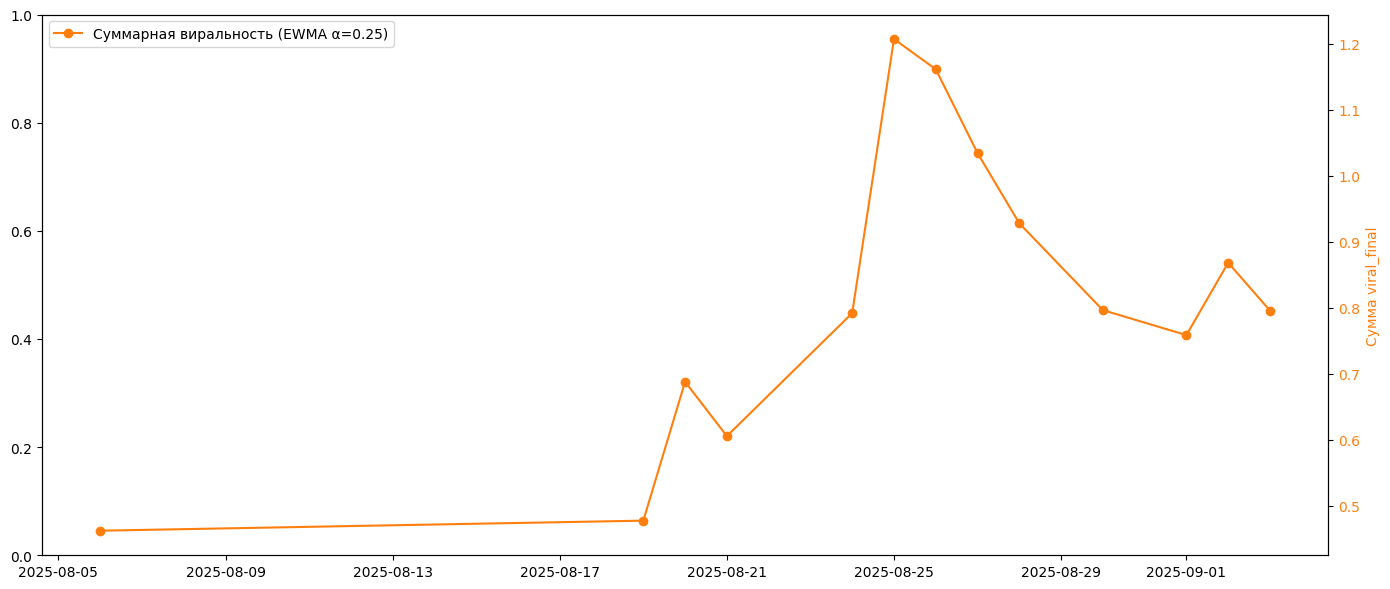

In [109]:
import matplotlib.pyplot as plt

# --- EWMA сглаживание ---
ALPHA = 0.25  # 0..1: больше = меньше сглаживание

daily_s = daily.sort_values("date_day").copy()
daily_s["mentions_s"]  = daily_s["mentions"].ewm(alpha=ALPHA, adjust=False).mean()
daily_s["viral_sum_s"] = daily_s["viral_sum"].ewm(alpha=ALPHA, adjust=False).mean()

fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

# 1) Mentions (левая ось)
# ax.plot(
#     daily_s["date_day"], daily_s["mentions_s"],
#     marker="o", color="tab:blue",
#     label=f"Упоминания (EWMA α={ALPHA})"
# )
# ax.set_title(f"Таймлайн темы: упоминания + суммарная виральность (judge >= {KEEP_JUDGE})")
# ax.set_xlabel("Дата")
# ax.set_ylabel("Упоминания (count)", color="tab:blue")
# ax.tick_params(axis="y", labelcolor="tab:blue")

# 2) Viral sum (правая ось)
ax_sum = ax.twinx()
ax_sum.plot(
    daily_s["date_day"], daily_s["viral_sum_s"],
    marker="o", color="tab:orange",
    label=f"Суммарная виральность (EWMA α={ALPHA})"
)
ax_sum.set_ylabel("Сумма viral_final", color="tab:orange")
ax_sum.tick_params(axis="y", labelcolor="tab:orange")

# Общая легенда (2 линии)
lines = ax.get_lines() + ax_sum.get_lines()
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

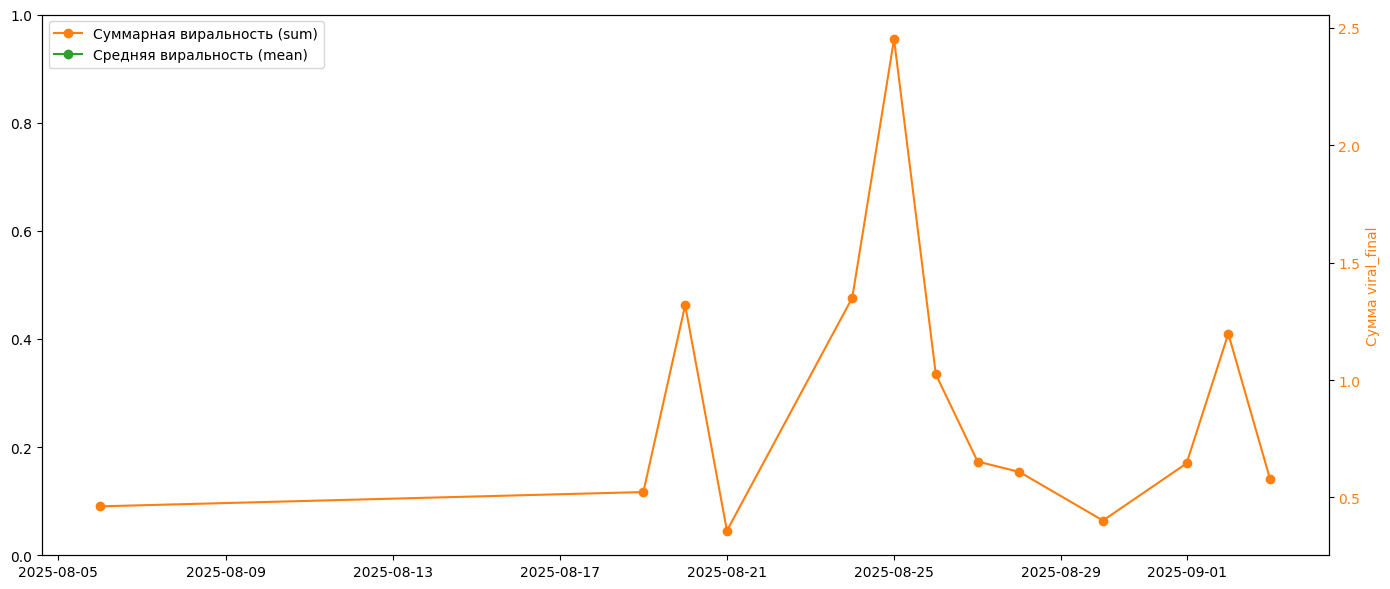

In [110]:
# %% [Cell 3-3axes] Mentions + viral_sum + viral_mean (3 разные шкалы)

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 6))
ax = plt.gca()

# 1) Mentions (левая ось)
# ax.plot(daily["date_day"], daily["mentions"], marker="o", color="tab:blue", label="Упоминания (count)")
# ax.set_title(f"Таймлайн темы: упоминания + суммарная и средняя виральность (judge >= {KEEP_JUDGE})")
# ax.set_xlabel("Дата")
# ax.set_ylabel("Упоминания (count)", color="tab:blue")
# ax.tick_params(axis="y", labelcolor="tab:blue")

# 2) Viral sum (правая ось)
ax_sum = ax.twinx()
ax_sum.plot(daily["date_day"], daily["viral_sum"], marker="o", color="tab:orange", label="Суммарная виральность (sum)")
ax_sum.set_ylabel("Сумма viral_final", color="tab:orange")
ax_sum.tick_params(axis="y", labelcolor="tab:orange")


# Общая легенда
lines = ax.get_lines() + ax_sum.get_lines() + ax_mean.get_lines()
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

In [111]:
d = daily.sort_values("date_day").copy()

q1 = d["viral_sum"].quantile(0.25)
q3 = d["viral_sum"].quantile(0.75)
iqr = q3 - q1

k = 1.5  # 1.5 обычный, 3.0 для супер-жёстких выбросов
hi = q3 + k * iqr
lo = q1 - k * iqr

out = d[(d["viral_sum"] > hi) | (d["viral_sum"] < lo)][["date_day", "viral_sum"]].sort_values("viral_sum", ascending=False)

print("Порог hi:", hi, "lo:", lo)
display(out)

outlier_dates = out["date_day"].tolist()
outlier_dates

Порог hi: 2.208888633524565 lo: -0.4886060555998114


,date_day,viral_sum
5,2025-08-25 00:00:00+00:00,2.452787


[Timestamp('2025-08-25 00:00:00+0000', tz='UTC')]

In [117]:
goldenset

,message_id,message,topic,reason,economic_narrative,narrative_strength,economic_effect,information_resonance,viral_final,id_channel,date
0,8c497c96-be46-4bb4-888f-25e40d20debb,#POSI \nГК Позитив — лидер в рейтинге покупок ...,Рынки капитала,Новость описывает активные покупки акций и изм...,0,0.00,0.00,0.00,0.440763,2,2025-07-01 13:28:09
1,63c159f3-4205-4477-bb06-e00c0bde9187,⚡️Россельхознадзор опроверг запрет на ввоз ман...,Международная торговля,Новость сообщает о заявленном запрете (и его о...,0,0.00,0.50,0.25,0.651092,1,2024-12-06 13:43:05
2,e189e8c9-28c2-4160-92e2-fc929057f2cc,Корпоративные бонды с доходностью 20-21%+ — се...,Рынки капитала,"Текст посвящён корпоративным облигациям, их до...",0,0.10,0.10,0.10,0.676079,2,2024-08-07 07:32:45
3,db2e74c1-fefa-4333-823c-6e0a527e87a0,#MTLR\n🪨 Мечел в 2025г может сократить отгрузк...,Корпоративные финансы,Новость описывает финансовые решения Mechel: с...,0,0.00,-0.25,0.25,0.544580,2,2025-06-30 06:51:47
4,031d93c6-89f0-426a-ada0-9f6f4174f4b7,Россия вошла в топ-5 стран по оттоку миллионер...,Макроэкономика,Новость сообщает о масштабном оттоке миллионер...,1,0.50,-0.50,0.75,0.636313,18,2024-06-19 05:31:11
...,...,...,...,...,...,...,...,...,...,...,...
495,968b6c17-2bc9-4828-9fac-6868b5a838db,⚡️Курс евро на межбанковском рынке опустился н...,Валютный рынок,Текст сообщает о движении курса евро к рублю н...,0,0.25,0.50,0.25,0.460295,1,2025-02-12 08:19:29
496,632250bd-e051-4061-a49f-6419180ac047,X5 стала лидером онлайн-продаж товаров повседн...,Корпоративные финансы,Новость содержит конкретные финансовые показат...,0,0.25,-0.25,0.00,0.405514,1,2025-02-20 11:25:06
497,75e06c71-8823-4cb5-9e13-8a96e003e11d,⚡️Минтруд РФ предложил не брать иностранцев на...,Государственная экономическая политика,Новость описывает предложение Минтруда о регул...,1,0.50,0.50,0.50,0.389320,1,2025-08-01 13:06:42
498,938733b1-c1d4-4d32-a457-968e22d280fd,"ЦБ и Минфин разошлись во мнении, как устранить...",Корпоративные финансы,Новость описывает налоговые проблемы при IPO и...,0,0.00,0.00,0.25,0.351437,6,2025-04-25 09:13:54


In [118]:
import pandas as pd

def build_llm_context_for_one_row(
    *,
    df,
    index,
    encoder,
    bm25,
    tokenize_fn,
    judge_llm,
    judge_tokenizer,
    message: str,
    anchor_date: str,          # 'YYYY-MM-DD'
    max_window_days: int = 30,
    keep_threshold: int = 1,   # keep_threshold для retrieve_and_judge
    keep_judge: int = 1,       # фильтр judge_relevance >= keep_judge
    topN_each: int = 10000,
    tau_sem_hi: float = 0.8,
    tau_sem_lo: float = 0.5,
    tau_bm25_lo: float = 1.0,
    iqr_k: float = 1.5,
) -> str:
    # 1) retrieve + judge
    cand = retrieve_and_judge(
        df=df,
        index=index,
        encoder=encoder,
        bm25=bm25,
        tokenize_fn=tokenize_fn,
        query=message,
        anchor_date=anchor_date,
        max_window_days=max_window_days,
        topN_each=topN_each,
        tau_sem_hi=tau_sem_hi,
        tau_sem_lo=tau_sem_lo,
        tau_bm25_lo=tau_bm25_lo,
        judge_llm=judge_llm,
        judge_tokenizer=judge_tokenizer,
        keep_threshold=keep_threshold,
    )

    if cand is None or len(cand) == 0:
        return (
            f"Опорная дата: {anchor_date}.\n"
            f"Запрос (текст новости): {message}\n\n"
            f"За окно {max_window_days} дней релевантных сообщений не найдено."
        )

    dfp = cand.copy()

    # 2) нормализуем поля
    dfp["date_day"] = pd.to_datetime(dfp["date_day"], errors="coerce", utc=True).dt.floor("D")
    dfp["viral_final"] = pd.to_numeric(dfp.get("viral_final", 0.0), errors="coerce").fillna(0.0).clip(0.0, 1.0)

    if "judge_relevance" in dfp.columns:
        dfp["judge_relevance"] = pd.to_numeric(dfp["judge_relevance"], errors="coerce").fillna(0).astype(int)
    else:
        dfp["judge_relevance"] = 1

    plot_df = dfp[dfp["judge_relevance"] >= keep_judge].copy()
    if len(plot_df) == 0:
        return (
            f"Опорная дата: {anchor_date}.\n"
            f"Запрос (текст новости): {message}\n\n"
            f"Кандидаты найдены (N={len(dfp)}), но после фильтра judge_relevance >= {keep_judge} ничего не осталось."
        )

    # 3) daily: mentions + viral_sum
    daily = (
        plot_df.groupby("date_day", as_index=False)
        .agg(
            mentions=("message", "size") if "message" in plot_df.columns else ("score_rrf", "size"),
            viral_sum=("viral_final", "sum"),
        )
        .sort_values("date_day")
    )

    # 4) IQR-выбросы по viral_sum
    q1 = daily["viral_sum"].quantile(0.25)
    q3 = daily["viral_sum"].quantile(0.75)
    iqr = q3 - q1
    hi = q3 + iqr_k * iqr
    lo = q1 - iqr_k * iqr

    out = daily[(daily["viral_sum"] > hi) | (daily["viral_sum"] < lo)][["date_day", "viral_sum"]].copy()
    out = out.sort_values("viral_sum", ascending=False)
    outlier_dates = [d.date().isoformat() for d in out["date_day"].tolist()]

    out_block = (
        f"Выделяющиеся даты по суммарной виральности за окно {max_window_days} дней: "
        f"{', '.join(outlier_dates) if outlier_dates else 'нет (по IQR)'}. "
        f"Пороги IQR: hi={hi:.3f}, lo={lo:.3f} (k={iqr_k})."
    )

    # 5) контекст по дням: сколько каналов + упоминания + viral_sum + список каналов
    by_day_ch = (
        plot_df.groupby(["date_day", "channel_name"], as_index=False)
        .agg(
            mentions=("message", "size") if "message" in plot_df.columns else ("score_rrf", "size"),
            viral_sum=("viral_final", "sum"),
        )
    )

    d = by_day_ch.copy()
    d["date"] = pd.to_datetime(d["date_day"], utc=True).dt.date

    daily_ctx = (
        d.groupby("date", as_index=False)
        .agg(
            channels_n=("channel_name", "nunique"),
            mentions=("mentions", "sum"),
            viral_sum=("viral_sum", "sum"),
            channels=("channel_name", lambda x: sorted(set(x))),
        )
        .sort_values("date")
    )

    daily_ctx["viral_sum"] = daily_ctx["viral_sum"].round(3)

    def make_paragraph(r):
        ch_list = ", ".join(r["channels"])
        return (
            f"Дата: {r['date']}. "
            f"Писали {r['channels_n']} канал(а/ов): {ch_list}. "
            f"Упоминаний: {int(r['mentions'])}. "
            f"Суммарный виральный скор: {r['viral_sum']} "
            f"(сумма реакций по всем новостям дня, где каждая новость имеет оценку от 0 до 1)."
        )

    body = "\n\n".join(daily_ctx.apply(make_paragraph, axis=1).tolist())

    return (
        f"Опорная дата: {anchor_date}.\n"
        f"Запрос (текст новости): {message}\n"
        f"Окно: {max_window_days} дней.\n\n"
        f"{out_block}\n\n"
        f"{body}"
    )


def add_llm_context_to_golden(
    gold_df: pd.DataFrame,
    *,
    msg_col: str = "message",
    date_col: str = "date",
    out_col: str = "llm_context",
    **kwargs,
) -> pd.DataFrame:
    g = gold_df.copy()

    # важно: идём по порядку строк таблицы (как ты просишь)
    contexts = []
    for _, row in g.iterrows():
        msg = str(row[msg_col])

        # anchor_date = YYYY-MM-DD
        anchor = pd.to_datetime(row[date_col], errors="coerce").date().isoformat()

        ctx = build_llm_context_for_one_row(
            message=msg,
            anchor_date=anchor,
            **kwargs,
        )
        contexts.append(ctx)

    g[out_col] = contexts
    return g

In [ ]:
goldenset = add_llm_context_to_golden(
    goldenset,
    df=df,
    index=index,
    encoder=encoder,
    bm25=bm25,
    tokenize_fn=tokenize_ru,
    judge_llm=model,
    judge_tokenizer=tokenizer,
    max_window_days=30,
    keep_threshold=1,
    keep_judge=1,
    topN_each=10000,
    tau_sem_hi=0.8,
    tau_sem_lo=0.5,
    tau_bm25_lo=1.0,
    iqr_k=1.5,
)

goldenset[["message_id", "date", "llm_context"]].head(3)

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/32 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [ ]:
goldenset.to_csv("goldenset_with_llm_context.csv")